# Lecture 11 · Character-level MLP language model (makemore-style)

**Goal** · build a fixed-context character MLP that predicts the next character in a small list of names, train it, and generate new names with temperature sampling. This is next-token prediction without recurrence.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.manual_seed(0)

## 1 · Tiny dataset + character vocabulary

`.` is the start/stop token. Small vocab (27 symbols) means embeddings are easy to see and training is fast.

In [2]:
names = ["emma","olivia","ava","isabella","sophia","mia","charlotte","amelia",
         "harper","evelyn","abigail","emily","ella","elizabeth","camila","luna",
         "sofia","avery","mila","aria","scarlett","penelope","layla","chloe",
         "victoria","riley","aurora","nora","hazel","lily","ellie","grace"]
chars = ['.'] + sorted(set(''.join(names)))
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}
V = len(chars)
print(f'{len(names)} names, vocab size V = {V}:', ''.join(chars))

32 names, vocab size V = 21: .abcefghilmnoprstuvyz


## 2 · Sliding-window dataset (context length $k=3$)

Every position in every name is one training example: 3 previous characters → next character.

In [3]:
k = 3
X, Y = [], []
for w in names:
    ctx = [0] * k
    for ch in w + '.':
        ix = stoi[ch]
        X.append(ctx); Y.append(ix)
        ctx = ctx[1:] + [ix]
X = torch.tensor(X); Y = torch.tensor(Y)
print('X (contexts):', tuple(X.shape), ' Y (targets):', tuple(Y.shape))
print('example  context', [itos[i] for i in X[5].tolist()], '-> target', itos[Y[5].item()])

X (contexts): (210, 3)  Y (targets): (210,)
example  context ['.', '.', '.'] -> target o


## 3 · The model: embedding → hidden → logits

Look up an embedding per context character, concatenate, pass through one hidden layer, output $V$ logits (the classic neural probabilistic language model).

In [4]:
d, Hdim = 8, 64
class MLP_LM(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(V, d)
        self.h = nn.Linear(k * d, Hdim)
        self.out = nn.Linear(Hdim, V)
    def forward(self, x):
        e = self.emb(x).view(x.shape[0], -1)   # (B, k*d)
        return self.out(torch.tanh(self.h(e)))

model = MLP_LM()
print('parameters:', sum(p.numel() for p in model.parameters()))

parameters: 3133


## 4 · Train

final loss: 0.567


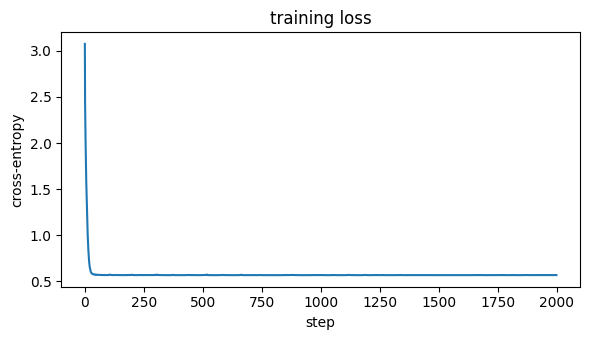

In [5]:
opt = torch.optim.Adam(model.parameters(), lr=0.05)
hist = []
for step in range(2000):
    logits = model(X)
    loss = F.cross_entropy(logits, Y)
    opt.zero_grad(); loss.backward(); opt.step()
    hist.append(loss.item())
print('final loss:', round(hist[-1], 3))
plt.figure(figsize=(6, 3.5)); plt.plot(hist)
plt.xlabel('step'); plt.ylabel('cross-entropy'); plt.title('training loss')
plt.tight_layout(); plt.show()

## 5 · Generate new names

Start from the empty context, sample the next character from $\mathrm{softmax}(z/\tau)$, append, repeat until the stop token `.`. Temperature $\tau<1$ = safer, $\tau>1$ = more diverse.

In [6]:
@torch.no_grad()
def generate(temp=0.8, max_len=15):
    ctx = [0] * k
    out = []
    for _ in range(max_len):
        logits = model(torch.tensor([ctx]))
        p = F.softmax(logits / temp, dim=1)
        ix = torch.multinomial(p, 1).item()
        if ix == 0:
            break
        out.append(itos[ix]); ctx = ctx[1:] + [ix]
    return ''.join(out)

torch.manual_seed(1)
print('sampled names:')
for _ in range(10):
    print('  ', generate())

sampled names:
   ava
   olivia
   camily
   evelyn
   layla
   harlett
   aurora
   ava
   sofia
   sofia


## Takeaway

- Language modelling = repeated next-token classification with cross-entropy.
- Embeddings turn discrete characters into learned vectors; concatenation keeps order.
- Autoregressive sampling (with temperature) turns the trained classifier into a generator.
- Limitation: the context is *fixed* at $k$ — which motivates RNNs next.